In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [2]:
X, y = make_moons(100, noise = 0.25, random_state  = 23)

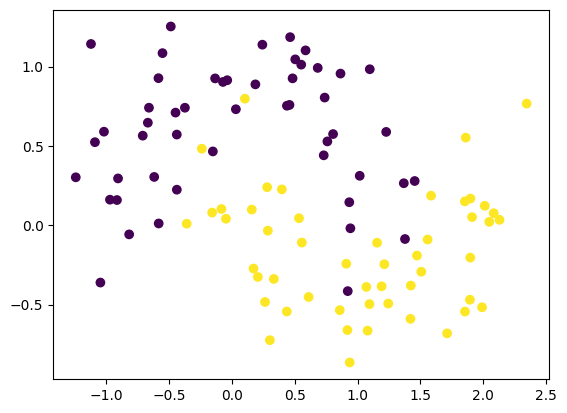

In [3]:
plt.scatter(X[:,0], X[:,1], c = y)
plt.show()

## BASE CASE WITHOUT REGULARIZATION

In [4]:
model1 = Sequential()
model1.add(Dense(128, input_dim = 2 , activation = 'relu'))
model1.add(Dense(128, activation = 'relu'))
model1.add(Dense(1, activation = 'sigmoid'))
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-17 07:30:36.354793: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
adam = Adam(learning_rate = 0.01)
model1.compile(loss = 'binary_crossentropy' , optimizer = adam , metrics = ['accuracy'])
history1 = model1.fit(X,y, epochs = 1000, validation_split = 0.2, verbose = 0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


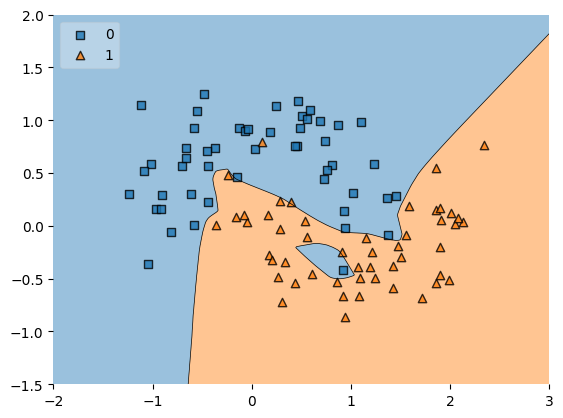

In [6]:
plot_decision_regions(
    X,
    y.astype('int'),
    clf=model1,
    legend=2
)

plt.xlim(-2, 3)
plt.ylim(-1.5, 2)

plt.show()

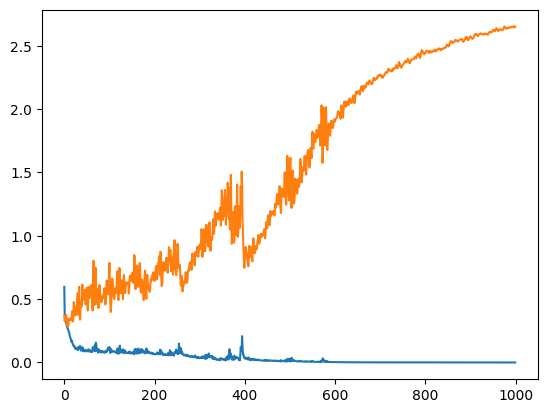

In [7]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

## L1 REGULARIZATION

In [8]:
model2 = Sequential()
model2.add(Dense(128, input_dim = 2 , activation = 'relu', kernel_regularizer = tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(128, activation = 'relu', kernel_regularizer = tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(1, activation = 'sigmoid'))
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
adam = Adam(learning_rate = 0.01)
model2.compile(loss= 'binary_crossentropy', optimizer = adam , metrics = ['accuracy'])
history2 = model2.fit(X, y , epochs = 1000, validation_split = 0.2, verbose = 0)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


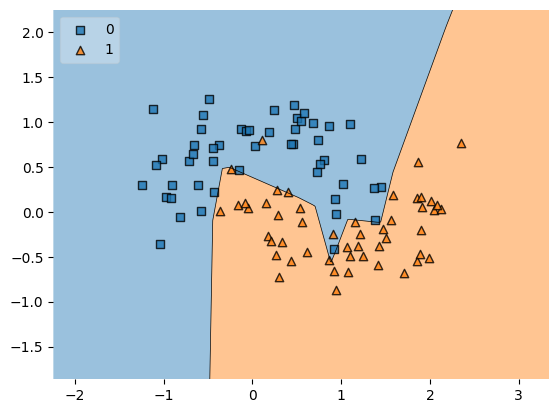

In [10]:
plot_decision_regions(X, y.astype('int'), clf = model2, legend = 2)
plt.xlim = (-2,3)
plt.ylim = (-1.5, 2)
plt.show()

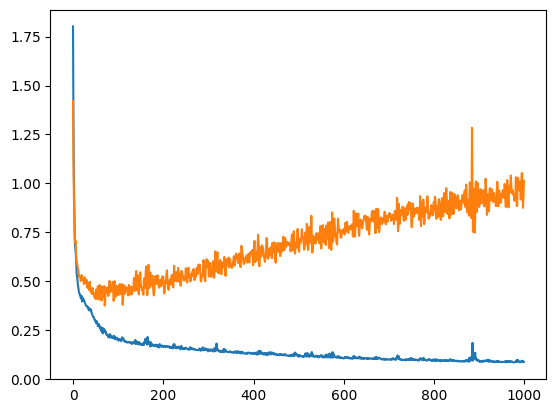

In [11]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

## L2 REGULARIZATION

In [12]:
model3 = Sequential()
model3.add(Dense(128, input_dim = 2 , activation = 'relu', kernel_regularizer = tensorflow.keras.regularizers.l2(0.001)))
model3.add(Dense(128, activation = 'relu', kernel_regularizer = tensorflow.keras.regularizers.l2(0.001)))
model3.add(Dense(1, activation = 'sigmoid'))
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
adam = Adam(learning_rate = 0.01)
model3.compile(loss= 'binary_crossentropy', optimizer = adam , metrics = ['accuracy'])
history3 = model3.fit(X, y , epochs = 1000, validation_split = 0.2, verbose = 0)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


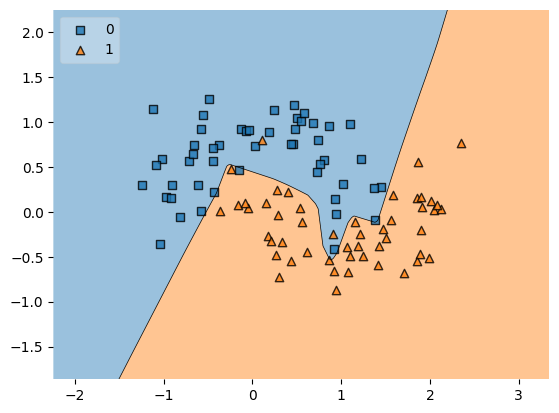

In [14]:
plot_decision_regions(X, y.astype('int'), clf = model3, legend = 2)
plt.xlim = (-2,3)
plt.ylim = (-1.5, 2)
plt.show()

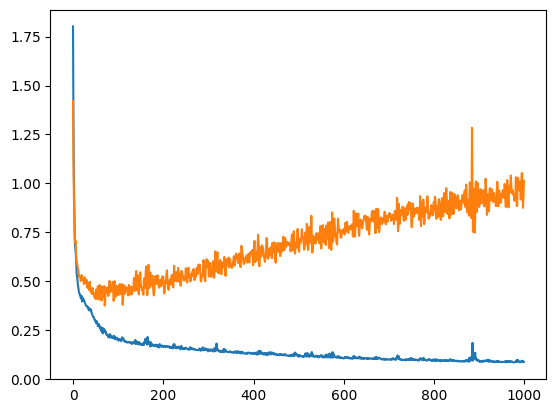

In [15]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [16]:
model1.get_weights()[0].reshape(256)

array([-4.53187376e-01,  4.65840667e-01, -9.67507958e-01, -2.50798225e-01,
       -6.91888511e-01, -9.63291451e-02, -8.83801997e-01,  3.25967431e-01,
       -4.50789511e-01, -9.30674970e-02, -2.25687310e-01, -3.77851844e-01,
        2.70176440e-01,  1.48502260e-01,  3.13852340e-01, -4.48429376e-01,
        3.36332172e-01, -8.74906600e-01, -3.99440914e-01,  3.11719388e-01,
        2.01649338e-01, -1.49262831e-01, -2.02517644e-01,  3.41189504e-01,
       -1.33835807e-01,  6.27289638e-02,  4.49923016e-02, -1.57764375e-01,
        2.83834308e-01, -2.18041778e-01, -5.54225147e-01, -3.01257353e-02,
       -3.54347914e-01,  4.34713811e-01, -2.61925608e-01, -1.35220659e+00,
       -5.06426990e-02,  3.61592114e-01, -4.96979505e-01,  4.07344103e-01,
        1.61693525e-02,  2.83897966e-01,  3.50642920e-01,  2.70640016e-01,
       -4.98917878e-01,  1.09326486e-02, -4.25658897e-02, -7.27491453e-02,
        4.10894990e-01, -3.75906199e-01,  3.07749867e-01, -1.84405267e-01,
       -3.91212523e-01, -

In [17]:
model1_weight_layer = model1.get_weights()[0].reshape(256)
model2_weight_layer = model2.get_weights()[0].reshape(256)
model2_weight_layer = model3.get_weights()[0].reshape(256)